<a href="https://colab.research.google.com/github/jiissung/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [44]:
# Step 1.1
np.random.seed(42)
zeroes = np.zeros(100)
tips = np.random.exponential(scale=5.0, size = 150)
driver_tips = np.concatenate([zeroes, tips])

# Step 1.2

median_list = []
for i in range(10000):
  sample = np.random.choice(driver_tips, size=250, replace=True)
  median = np.median(sample)
  median_list.append(median)

ci = np.percentile(median_list, [2.5, 97.5])
print(ci)

[0.26530184 1.36356392]


In [45]:
# Step 2.1

control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)
mean_diff = np.mean(control) - np.mean(treatment)

# Step 2.2

array = np.concatenate([control, treatment])
perms_diff = []

for i in range(5000):
  shuffled_array = np.random.permutation(array)
  shuffled_control = shuffled_array[:500]
  shuffled_treatment = shuffled_array[500:]
  perms_diff.append(np.mean(shuffled_control) - np.mean(shuffled_treatment))

perm_diffs = np.array(perms_diff)
p_value = np.mean(np.abs(perm_diffs) >= abs(mean_diff))
print(p_value)


0.0022


In [46]:
# Step 3.1

df = pd.read_csv("swiftcart_loyalty.csv")

subbed = df[df["subscriber"] == 1]["post_spend"]
non_subbed = df[df["subscriber"] == 0]["post_spend"]

sdo = np.mean(subbed) - np.mean(non_subbed)
print("SDP:", sdo)

SDP: 17.57066938452379


In [48]:
# Step 3.2

X = df.drop(columns=["subscriber", "post_spend"])
y = df["subscriber"]

model = LogisticRegression(solver="liblinear")
model.fit(X, y)

df["pscore"] = model.predict_proba(X)[:,1]

treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]

knn_model = NearestNeighbors(n_neighbors=5)
knn_model.fit(control[["pscore"]])
distances, indices = knn_model.kneighbors(treated[["pscore"]])
matched_control = control.iloc[indices.flatten()]

matched_df = pd.concat([treated, matched_control])
att = treated["post_spend"].mean() - matched_control["post_spend"].mean()

print("ATT:", att)

ATT: 10.002208700853686


The SDO does compares solely the average spending between subscribers and non-subscribers. SDO does not take into account any potential biases, such as high-volume spenders are more likely to purchase a loyalty program because they use the program more. This causes SDO to overapproximate the effect the subscription has on spending.

PSM accounts for this bias by including a probability of subscribing based on account, spending, and order history.

Therefore, the ATT value is smaller than the SDO value because it compares subscribers with similar circumstances rathger than the entire population.

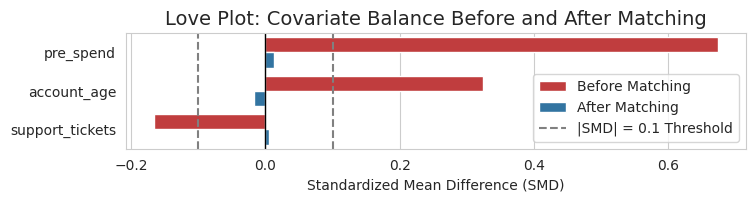

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Step 1: Define function to compute Standardized Mean Differences (SMD)
# -----------------------------
def compute_smd(df_treated, df_control, covariates):
    smd_dict = {}
    for cov in covariates:
        mean_t = df_treated[cov].mean()
        mean_c = df_control[cov].mean()
        var_t = df_treated[cov].var()
        var_c = df_control[cov].var()
        smd = (mean_t - mean_c) / np.sqrt((var_t + var_c) / 2)
        smd_dict[cov] = smd
    return smd_dict

# -----------------------------
# Step 2: Identify covariates (exclude treatment/outcome)
# -----------------------------
covariates = [c for c in df.columns if c not in ["subscriber", "post_spend", "pscore"]]

# -----------------------------
# Step 3: Compute SMDs before and after matching
# -----------------------------
smd_before = compute_smd(
    df[df["subscriber"] == 1],
    df[df["subscriber"] == 0],
    covariates
)

smd_after = compute_smd(
    matched_df[matched_df["subscriber"] == 1],
    matched_df[matched_df["subscriber"] == 0],
    covariates
)

# Convert to DataFrame for plotting
smd_df = pd.DataFrame({
    "Covariate": covariates,
    "Before Matching": [smd_before[c] for c in covariates],
    "After Matching": [smd_after[c] for c in covariates]
}).melt(id_vars="Covariate", var_name="Stage", value_name="SMD")

# -----------------------------
# Step 4: Create Love Plot
# -----------------------------
plt.figure(figsize=(8, len(covariates) * 0.5))
sns.set_style("whitegrid")

sns.barplot(x="SMD", y="Covariate", hue="Stage", data=smd_df, palette=["#d62728", "#1f77b4"])
plt.axvline(x=0, color="black", linewidth=1)
plt.axvline(x=0.1, color="gray", linestyle="--", label="|SMD| = 0.1 Threshold")
plt.axvline(x=-0.1, color="gray", linestyle="--")
plt.title("Love Plot: Covariate Balance Before and After Matching", fontsize=14)
plt.xlabel("Standardized Mean Difference (SMD)")
plt.ylabel("")
plt.legend(loc="lower right")
plt.show()

Theoretical Evidence of Bias Mitigation

To conclude that selection bias has been mitigated:

SMDs should be close to 0 after matching:

Rule of thumb: |SMD| < 0.1 (some use 0.2 for looser criteria).

Visually, all bars “after matching” should be near the vertical zero line.

Before vs After Comparison:

Large SMDs before matching indicate severe baseline differences.

A successful PSM should reduce all covariate SMDs substantially toward zero.

Consistency Across Covariates:

No remaining covariate should show extreme imbalance post-matching.

Even one poorly balanced covariate can indicate residual bias.

Visual Diagnostics Supplement, Not Replace, Formal Checks:

Love Plot is graphical evidence, but researchers often report numerical SMD tables alongside the plot.